<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">

# Classifying CAD parts by training an MLP on shape embeddings

This tutorial solves the labeling problem a **second way**. The companion notebook
[`demo_HOOPS_Embeddings_Multi-labeling.ipynb`](./demo_HOOPS_Embeddings_Multi-labeling.ipynb)
needs **no training**: it retrieves look-alike parts and aggregates their tags. Here we put
on a **data-scientist hat** and *train our own classifier* on top of the same embeddings.

**The idea in one line:** a HOOPS shape embedding is a 2048-dim vector that already describes
the 3D geometry well, so a small **MLP** placed on top only has to learn the **decision
boundaries** between categories — fast to train, and entirely yours to customize.

**Why this is attractive.** The expensive part (turning B-rep geometry into a meaningful
vector) is already done by the pre-trained embedding model. You reuse those vectors as the
input features `X` of a standard supervised pipeline and own every downstream choice —
architecture, loss, optimizer, decision rule.

**Two flavours of the same recipe.** TMCAD gives **one** category per part, so we build the
natural **single-label** classifier first (softmax + cross-entropy + argmax). At the end we
show that switching to **multi-label** — where a part may carry several tags at once — is
only a change of *target*, *loss*, and *decision rule* (sigmoid + BCE + threshold); the
architecture and training loop are untouched.

| | Single-label (this notebook) | Multi-label (variant at the end) |
|---|---|---|
| **Output activation** | softmax (labels compete) | sigmoid (labels independent) |
| **Loss** | cross-entropy | binary cross-entropy |
| **Decision** | argmax (one winner) | threshold (a set of labels) |

**Prerequisites — an embeddings index.** We reuse the FAISS index built by
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb) purely as a
convenient store of pre-computed vectors — no re-embedding required. To classify **your own**
parts, build your own index with that notebook (point it at your CAD folders) and load it
here instead.

## Dataset — TMCAD

~10,000 STEP models across 10 mechanical categories (bearing, bolt, bracket, coupling,
flange, gear, nut, pulley, screw, shaft). The category is encoded in each file's parent
folder, which gives us ground-truth labels for free.

- TMCAD v2 (recommended): <https://pan.zju.edu.cn/share/218d10a88e8c18f5b96e94a7e0>
- Documentation: <https://github.com/Qiang-Zou/BRT/blob/main/DATASET.md>

> Zou, Q., & Zhu, L. (2025). Bringing attention to CAD: Boundary representation learning via transformer. *Computer-Aided Design*, 103940. Released under **GPL-3.0**.


## Workflow at a glance

![MLP classifier workflow](../images/workflow_mlp_classifier.png)


In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.2.0.dev
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-06-12T10:38:16Z)
  Conversion    : hoops-converter      26.1.1  (build: 00dc9f6 2026-06-12T10:22:46Z)
  Insights      : hoops-web-viewer     26.1.1  (build: d30058f 2026-06-12T10:22:25Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


## 1. Load the pre-computed embeddings (our feature matrix `X`)

We reuse the FAISS index from the indexing notebook as a ready-made store of embeddings.
`load_shape_index` returns an `EmbeddingBatch` whose `.values` is the `(n_parts, 2048)`
feature matrix and whose `.ids` are the original CAD file paths.

> **Use your own parts:** run
> [`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb) on your
> own CAD folders to produce a `.faiss` index, then point `indexed_database` below at it. The
> rest of this notebook is dataset-agnostic.


In [2]:
from hoops_ai.ml.embeddings import HOOPSEmbeddings
from hoops_ai.ml import CADSearch
import numpy as np
import pathlib

packages_dir = pathlib.Path.cwd().parent.joinpath("packages")
pretrained_model = packages_dir.joinpath("trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt")
indexed_database = packages_dir.joinpath("vectorstores", "tmcad", "TMCAD_SIGNAL.faiss")
demo_cad_files_folder = packages_dir.joinpath("vectorstores", "tmcad", "queries_for_demo")

# The embedder is only needed later, to embed brand-new query files at inference time.
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pretrained_model),
)
embedder = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview")

# Load the index purely as a store of pre-computed vectors.
searcher = CADSearch(shape_model=embedder)
embeddingBatch = searcher.load_shape_index(path=str(indexed_database))

X = np.asarray(embeddingBatch.values, dtype=np.float32)   # (n_parts, 2048) feature matrix
ids = list(embeddingBatch.ids)                            # CAD file paths
print(f"Loaded {X.shape[0]} embeddings of dimension {X.shape[1]}.")

Successfully loaded model from checkpoint: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt
Loaded 39736 embeddings of dimension 2048.


## 2. Build the labels `y`

Each TMCAD part lives in a folder named after its category, so the **parent folder is the
ground-truth label**. We turn those folder names into integer class indices `y` — the format
`CrossEntropyLoss` expects for single-label classification.

The index also contains a handful of stand-alone demo query files (in a `queries_for_demo`
folder) that are **not** a real category; we drop them so they don't pollute the class list
or leak into training.


In [3]:
from collections import Counter

EXCLUDED_FOLDERS = {"queries_for_demo"}   # demo query files, not a real category


def category_of(part_id: str) -> str:
    """TMCAD stores each part under a folder named after its category."""
    return pathlib.PurePath(part_id).parent.name


# Keep only parts whose parent folder is a real category.
keep = [k for k, pid in enumerate(ids) if category_of(pid) not in EXCLUDED_FOLDERS]
X = X[keep]
ids = [ids[k] for k in keep]
labels = [category_of(pid) for pid in ids]

classes = sorted(set(labels))
class_to_idx = {name: k for k, name in enumerate(classes)}
n_classes = len(classes)

# Integer class targets: one label per part (single-label classification).
y = np.array([class_to_idx[name] for name in labels], dtype=np.int64)

# L2-normalize the embeddings. They come from a contrastive model, so unit-norm
# features train more stably and keep logit magnitudes (and softmax confidence)
# in a sensible range.
X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)

print(f"{n_classes} categories: {classes}")
print("counts per category:", dict(Counter(labels)))
print("X:", X.shape, " y:", y.shape)


10 categories: ['bearing', 'bolt', 'bracket', 'coupling', 'flange', 'gear', 'nut', 'pulley', 'screw', 'shaft']
counts per category: {'bearing': 7541, 'bolt': 1800, 'bracket': 2176, 'coupling': 11196, 'flange': 1313, 'gear': 1952, 'nut': 1241, 'pulley': 7212, 'screw': 1425, 'shaft': 3860}
X: (39716, 2048)  y: (39716,)


## 3. Split the data and wrap it for PyTorch

A standard stratified **train / validation / test** split (70 / 15 / 15). The validation set
guides early choices (epochs, learning rate); the test set is touched only once, for the
final report.


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)

idx = np.arange(len(ids))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42, stratify=y)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=y[temp_idx]
)
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y)


def make_loader(indices, batch_size=512, shuffle=False, drop_last=False):
    ds = TensorDataset(X_t[indices], y_t[indices])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)


# drop_last on train avoids a size-1 final batch breaking BatchNorm.
train_loader = make_loader(train_idx, shuffle=True, drop_last=True)
val_loader = make_loader(val_idx)
test_loader = make_loader(test_idx)

Training on: cuda
train=27801  val=5957  test=5958


## 4. Define the MLP (the part you customize)

The classifier is a plain PyTorch `nn.Module`: a stack of fully-connected layers mapping the
2048-dim embedding to `n_classes` **raw logits**. Note what is *not* here — there is **no
final activation**. Keeping the head as logits lets the same network serve both problems: we
attach the sigmoid/softmax inside the **loss**, where it belongs.

Edit freely: change the hidden sizes, swap `ReLU` for `GELU`, add or remove `Dropout` /
`BatchNorm`, make it deeper or shallower. This is your model.


In [5]:
import torch.nn as nn


class EmbeddingMLP(nn.Module):
    """A small classifier head over a shape-embedding vector.

    Outputs raw logits (no softmax/sigmoid) so the same module works for both
    single-label (cross-entropy) and multi-label (BCE-with-logits) training.
    """

    def __init__(self, in_dim: int, n_classes: int, hidden=(512, 256), dropout: float = 0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for width in hidden:
            layers += [nn.Linear(prev, width), nn.BatchNorm1d(width), nn.ReLU(), nn.Dropout(dropout)]
            prev = width
        layers.append(nn.Linear(prev, n_classes))   # raw logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


print(EmbeddingMLP(X.shape[1], n_classes))

EmbeddingMLP(
  (net): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 5. Train the classifier (softmax + cross-entropy)

For single-label classification the standard choice is **`CrossEntropyLoss`**: it applies a
**softmax across the classes** (so they compete for the probability mass) and penalises the
log-probability of the true class. `nn.CrossEntropyLoss` does the softmax internally, which
is why the MLP outputs raw logits.

The categories are imbalanced (coupling has ~11k parts, nut ~1.2k), so we pass per-class
**weights** — a one-line way to stop the big classes from dominating.

A few small but important training hygiene knobs:

- **`label_smoothing=0.05`** — slightly soft targets instead of one-hot. A light touch of
  regularization that also discourages the model from driving the softmax to exactly 1.0.
- **Cosine LR schedule over the full epoch budget** — anneals the learning rate smoothly so
  the optimizer actually settles into a good minimum.
- **Best-validation checkpointing** — we track the lowest val loss and restore those weights
  at the end. Without it, training past the val-loss minimum quietly degrades the model.



In [6]:
# Per-class weights counter the imbalance (computed on the training split only).
counts = np.bincount(y[train_idx], minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(
    len(train_idx) / (n_classes * np.clip(counts, 1.0, None)),
    dtype=torch.float32, device=device,
)

model = EmbeddingMLP(X.shape[1], n_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 120
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * xb.size(0)
    return total / len(loader.dataset)


best_val = float("inf")
best_epoch = 0
best_state = None
for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    scheduler.step()
    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:3d}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}")

# Restore the weights from the best validation epoch (early stopping by selection).
model.load_state_dict(best_state)
print(f"\nbest val_loss = {best_val:.4f} at epoch {best_epoch}")


epoch   1  train_loss 1.7064  val_loss 2.0265
epoch  10  train_loss 1.0637  val_loss 1.1222
epoch  20  train_loss 0.9116  val_loss 1.0375
epoch  30  train_loss 0.8424  val_loss 1.0199
epoch  40  train_loss 0.7906  val_loss 0.9964
epoch  50  train_loss 0.7531  val_loss 0.9873
epoch  60  train_loss 0.7292  val_loss 0.9785
epoch  70  train_loss 0.7061  val_loss 0.9725
epoch  80  train_loss 0.6940  val_loss 0.9653
epoch  90  train_loss 0.6799  val_loss 0.9631
epoch 100  train_loss 0.6700  val_loss 0.9599
epoch 110  train_loss 0.6699  val_loss 0.9590
epoch 120  train_loss 0.6670  val_loss 0.9584

best val_loss = 0.9584 at epoch 120


## 6. Evaluate

The decision rule is **argmax** over the class scores. We report overall **accuracy** and a
per-class **precision / recall / F1** breakdown, so you can see which categories are easy
(bearing, coupling) and which get confused (e.g. bolt vs. screw).


In [7]:
from sklearn.metrics import accuracy_score, classification_report


@torch.no_grad()
def predict_class(indices):
    model.eval()
    logits = model(X_t[indices].to(device))
    return logits.argmax(dim=1).cpu().numpy()


test_pred = predict_class(test_idx)
test_true = y[test_idx]

print(f"accuracy: {accuracy_score(test_true, test_pred):.3f}\n")
print(classification_report(test_true, test_pred, target_names=classes, zero_division=0))

accuracy: 0.802

              precision    recall  f1-score   support

     bearing       0.85      0.85      0.85      1131
        bolt       0.85      0.91      0.88       270
     bracket       0.78      0.82      0.80       327
    coupling       0.90      0.81      0.85      1680
      flange       0.61      0.82      0.70       197
        gear       0.67      0.78      0.72       293
         nut       0.76      0.83      0.79       186
      pulley       0.74      0.73      0.74      1082
       screw       0.69      0.85      0.76       213
       shaft       0.79      0.75      0.77       579

    accuracy                           0.80      5958
   macro avg       0.76      0.81      0.79      5958
weighted avg       0.81      0.80      0.80      5958



## 7. Calibrate the confidence scores (temperature scaling)

Argmax-accuracy and **probability quality** are two different things. With weighted
cross-entropy and a flexible head, the trained model tends to drive its top logit very high,
so the softmax saturates near `1.0` even when the prediction is wrong. The classic, one-line
remedy is **temperature scaling**: fit a single scalar `T > 0` on the validation set that
minimises NLL when we divide the logits by it before softmax.

- It **does not change the argmax**, so test accuracy is unaffected.
- It **rescales the probabilities** so a "99.9% bearing" turns into something like
  "82% bearing" — much closer to the model's true reliability.
- It's a standard post-hoc calibration step (Guo et al., 2017, *On Calibration of Modern
  Neural Networks*).

We fit `T` here once on the held-out validation logits and reuse it everywhere the model is
queried.



In [8]:
import torch.nn.functional as F


@torch.no_grad()
def _logits_for(indices):
    model.eval()
    return model(X_t[indices].to(device)).detach()


val_logits = _logits_for(val_idx)
val_targets = torch.from_numpy(y[val_idx]).to(device)

# A single scalar parameter; plain (unweighted) NLL on val measures pure calibration.
T = nn.Parameter(torch.ones(1, device=device))
nll = nn.CrossEntropyLoss()
opt = torch.optim.LBFGS([T], lr=0.1, max_iter=100)


def _closure():
    opt.zero_grad()
    loss = nll(val_logits / T.clamp(min=1e-3), val_targets)
    loss.backward()
    return loss


opt.step(_closure)
TEMPERATURE = float(T.detach().clamp(min=1e-3).item())

# Quick before/after look: how confident is the model on its test predictions?
test_logits = _logits_for(test_idx)
raw_conf = F.softmax(test_logits, dim=1).max(dim=1).values.cpu().numpy()
cal_conf = F.softmax(test_logits / TEMPERATURE, dim=1).max(dim=1).values.cpu().numpy()

print(f"calibrated temperature T = {TEMPERATURE:.3f}")
print(f"mean top-1 confidence  : raw {raw_conf.mean():.3f}  -> calibrated {cal_conf.mean():.3f}")
print(f"share of predictions ≥ 99% : raw {(raw_conf >= 0.99).mean():.1%}"
      f"  -> calibrated {(cal_conf >= 0.99).mean():.1%}")


calibrated temperature T = 0.825
mean top-1 confidence  : raw 0.736  -> calibrated 0.801
share of predictions ≥ 99% : raw 3.2%  -> calibrated 11.1%


## 8. Classify a brand-new CAD file — with a preview

End to end on files the model never saw: **embed** each one with `HOOPSEmbeddings`, push the
vector through the trained MLP, divide the logits by the calibrated `TEMPERATURE`, take the
**softmax**, and read off the most likely category. The bundled `queries_for_demo` parts
were *excluded* from training, so they are genuinely unseen.

A couple of details worth getting right:

- **Multi-body parts.** `embed_shape` returns *one embedding per body* for assemblies. We
  **average** them instead of taking only the first body, so the full part contributes to
  the prediction.
- **Match the training-time feature scaling.** We L2-normalized `X` before training, so we
  apply the same normalization to the query vector before running the model.
- **Apply temperature scaling.** Dividing logits by the calibrated `T` from section 7 gives
  probabilities that reflect the model's real reliability instead of an over-confident
  near-1.0 on every top class.

To make the result tangible, we also show each part's **rendered preview**. The vector store
keeps a PNG thumbnail for every part under `images_tmcad/<category>/<name>_white.png`, so we
can locate it straight from the CAD file path and display it next to the prediction.



geargear: 59.6%shaft: 38.9%nut: 0.5%top logit: 3.41,geargear: 95.4%pulley: 1.3%bearing: 0.9%top logit: 3.74,geargear: 99.7%screw: 0.1%bracket: 0.0%top logit: 6.20,geargear: 99.1%flange: 0.3%shaft: 0.2%top logit: 5.11,bracketbracket: 99.3%bolt: 0.2%coupling: 0.1%top logit: 5.18

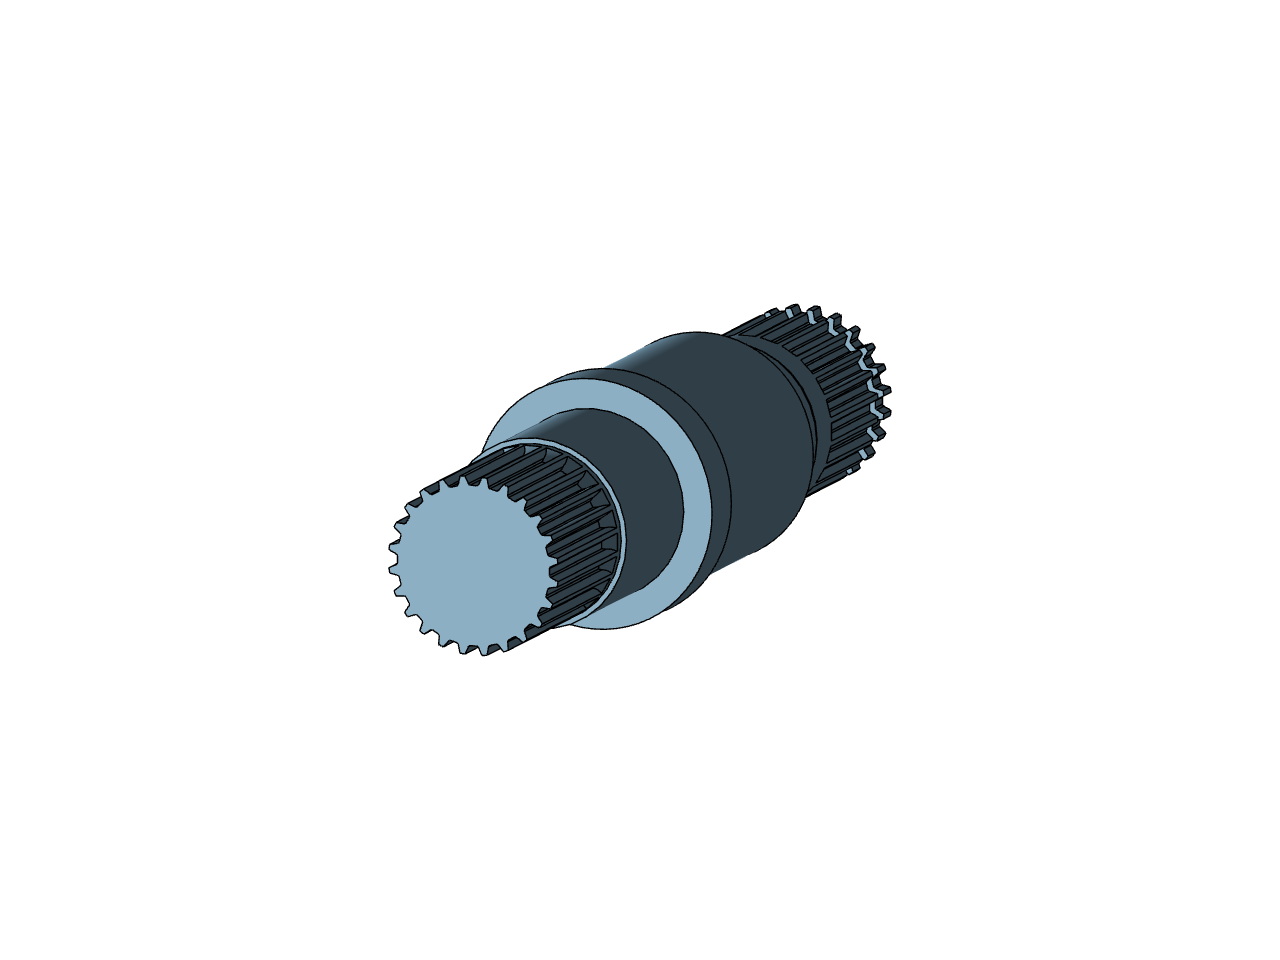
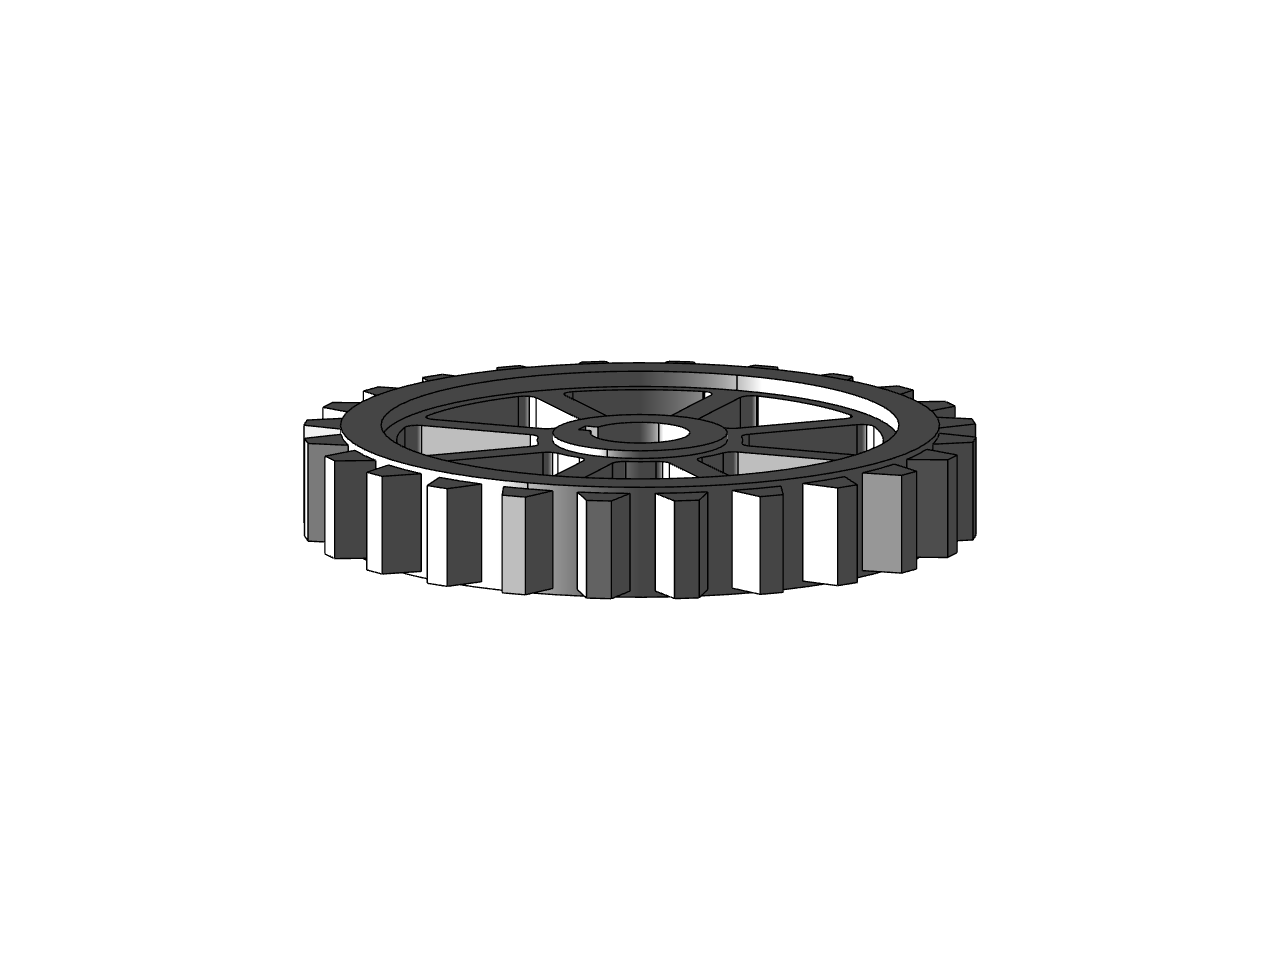
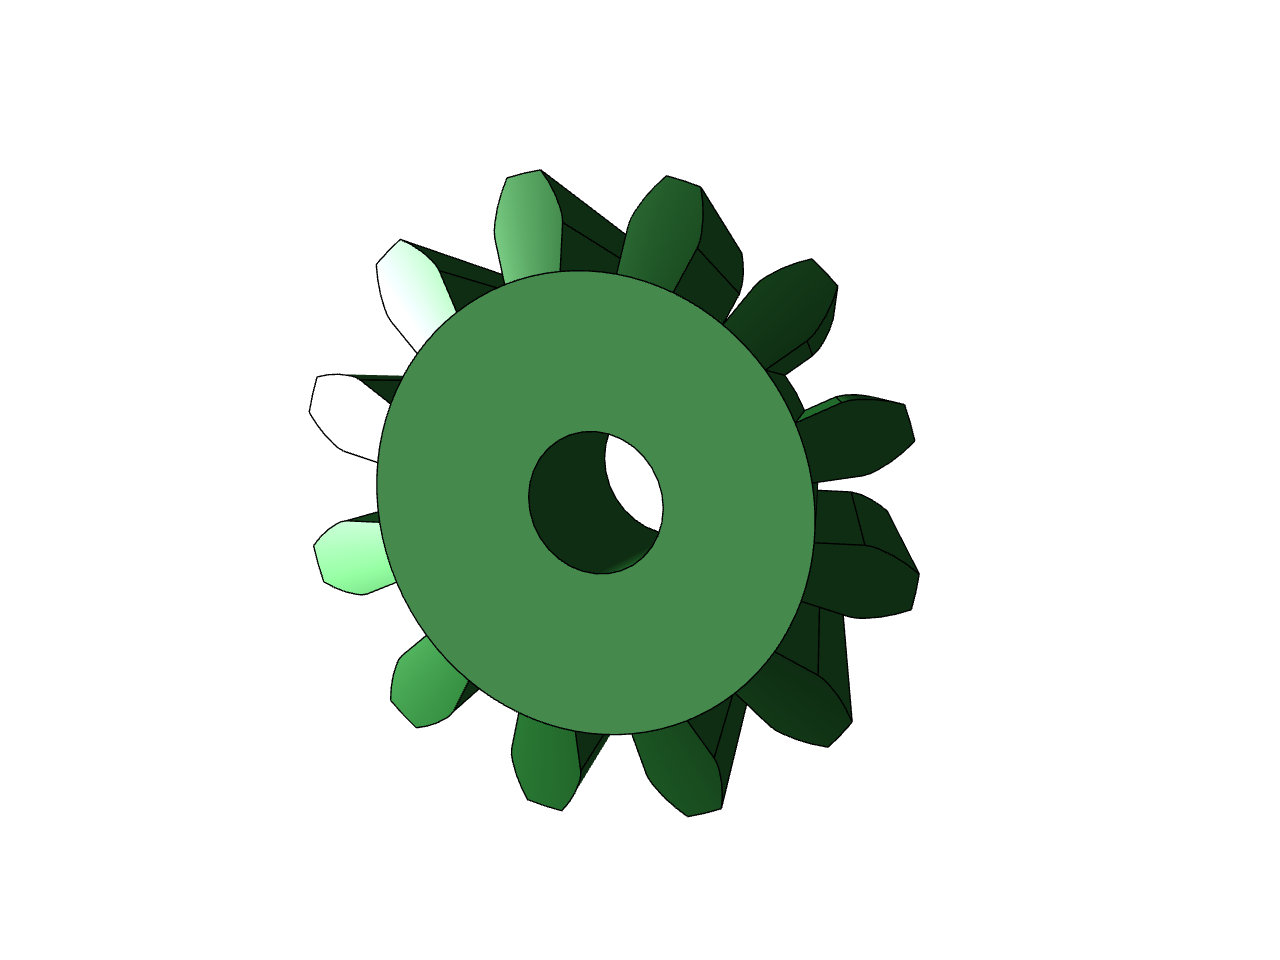
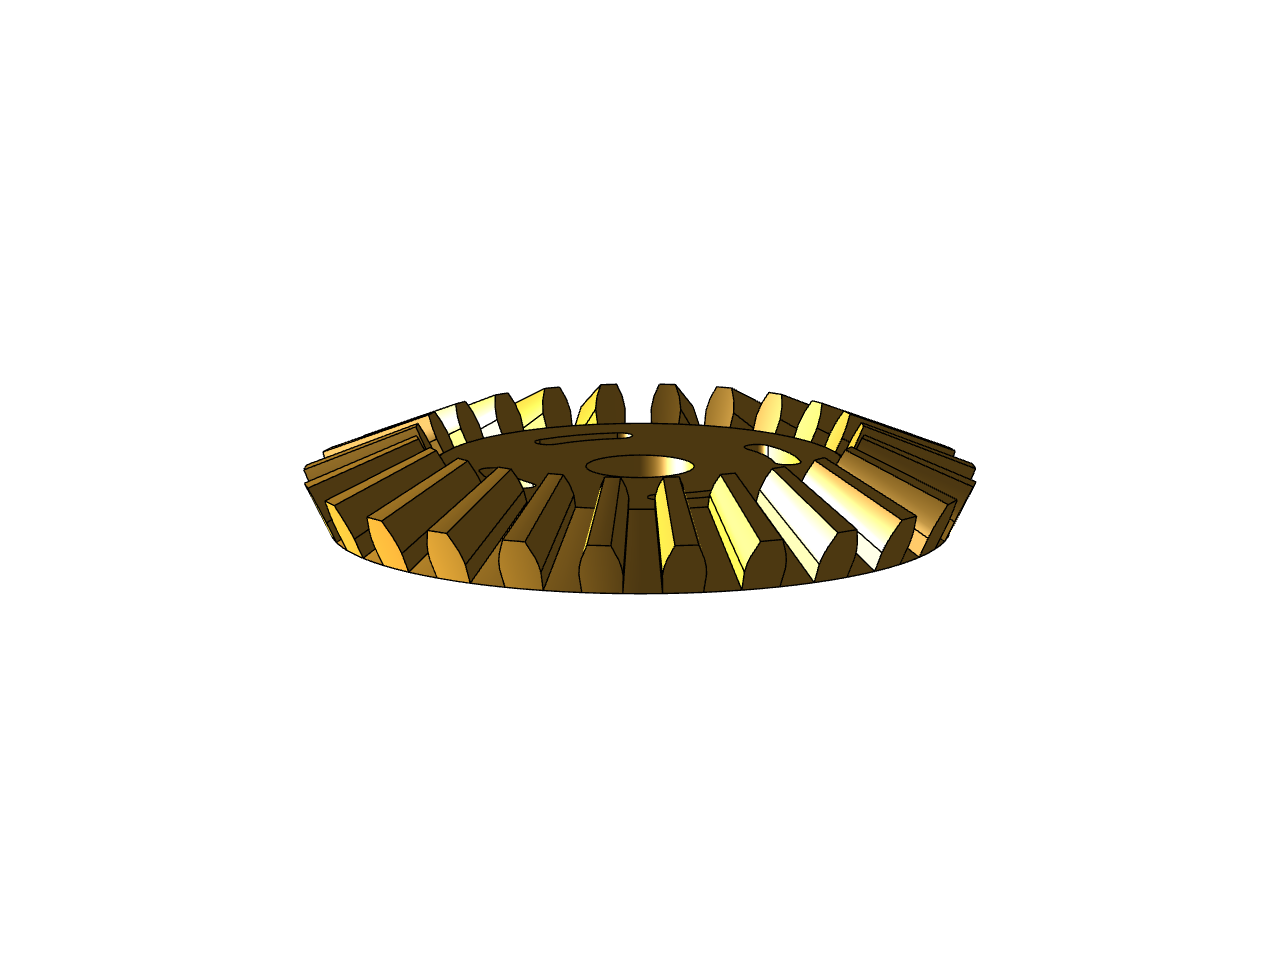
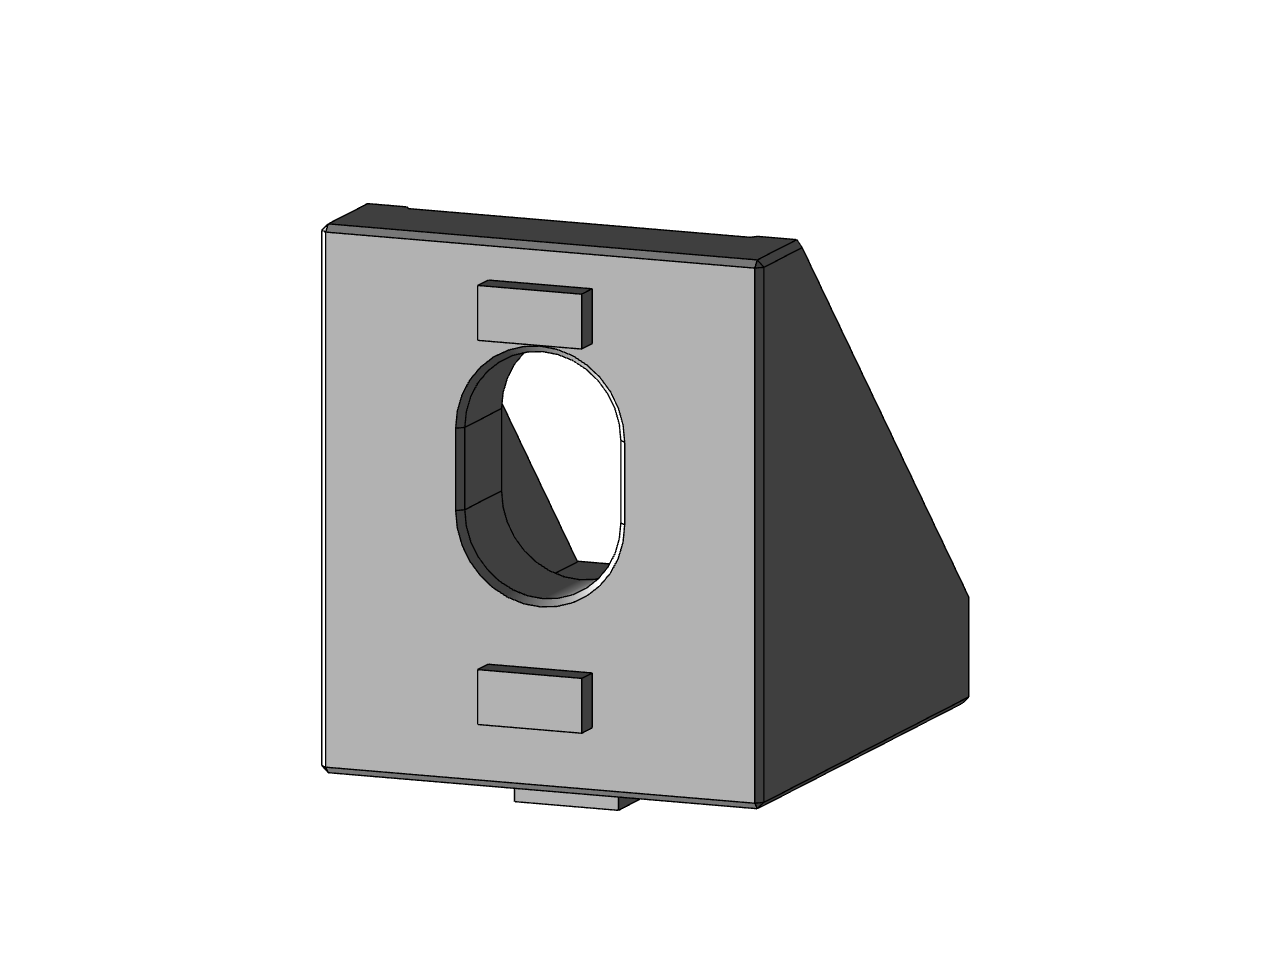

In [9]:
import base64
import torch.nn.functional as F
from IPython.display import HTML, display
from hoops_ai.storage import CADFileRetriever, LocalStorageProvider

retriever = CADFileRetriever(
    storage_provider=LocalStorageProvider(directory_path=demo_cad_files_folder),
    formats=[".stp", ".step", ".iges", ".igs"],
)
cad_files = retriever.get_file_list()

# The vector store keeps a rendered preview per part: images_tmcad/<category>/<name>_white.png
images_root = packages_dir.joinpath("vectorstores", "tmcad", "images_tmcad")


def preview_png(cad_path: str):
    """Locate the rendered preview the vector store stores for this part (or None)."""
    p = pathlib.PurePath(cad_path)
    candidate = images_root.joinpath(p.parent.name, f"{p.stem}_white.png")
    return candidate if candidate.exists() else None


def classify_cad(cad_path: str, top_k: int = 3):
    emb = embedder.embed_shape(str(cad_path))
    # Multi-body parts return one Embedding per body — average them so the
    # prediction reflects the whole part instead of just the first body.
    if isinstance(emb, (list, tuple)):
        feat = np.mean(
            np.stack([np.asarray(e.values, dtype=np.float32) for e in emb]),
            axis=0,
        )
    else:
        feat = np.asarray(emb.values, dtype=np.float32)
    # Match the L2-normalization applied to the training features.
    feat = feat / max(np.linalg.norm(feat), 1e-12)
    vec = torch.from_numpy(feat).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(vec)
        probs = F.softmax(logits / TEMPERATURE, dim=1).cpu().numpy()[0]
        top_logit = float(logits.max().item())
    ranked = sorted(zip(classes, probs), key=lambda kv: kv[1], reverse=True)
    return ranked[0][0], ranked[:top_k], top_logit


def _img_tag(png_path, size: int = 150):
    data = base64.b64encode(pathlib.Path(png_path).read_bytes()).decode("ascii")
    return f'<img src="data:image/png;base64,{data}" width="{size}" />'


# Classify each unseen part and show its preview next to the top-3 predictions.
cards = []
for query in cad_files[:5]:
    predicted, top, top_logit = classify_cad(str(query))
    png = preview_png(query)
    thumb = _img_tag(png) if png else "<div style='height:150px'>(no preview)</div>"
    scores = "".join(f"<div>{name}: {prob:.1%}</div>" for name, prob in top)
    cards.append(
        "<td style='text-align:center;padding:10px;vertical-align:top'>"
        f"{thumb}"
        f"<div style='font-weight:bold;margin-top:6px'>{predicted}</div>"
        f"<div style='font-size:0.85em;color:#555;margin-top:2px'>{scores}</div>"
        f"<div style='font-size:0.75em;color:#888;margin-top:4px'>top logit: {top_logit:.2f}</div>"
        "</td>"
    )

display(HTML(f"<table><tr>{''.join(cards)}</tr></table>"))


## 9. Variant — multi-label classification (what changes)

TMCAD parts have a single category, so the classifier above is all this dataset needs. But
the **same MLP** becomes a multi-label classifier — able to assign *several* tags to one part
— with three local changes and nothing else:

| | Single-label (above) | Multi-label (here) |
|---|---|---|
| **Targets** | class index `y` | binary matrix `Y` (a `1` per active tag) |
| **Loss** | `CrossEntropyLoss` (softmax) | `BCEWithLogitsLoss` (independent sigmoids) |
| **Decision** | `argmax` (one winner) | `prob >= threshold` (a set of labels) |

Because our labels are still single-tag, each row of `Y` has exactly one `1`, so the cell
below mainly *illustrates the mechanics*. With a catalog that tags a part as, say, both
`bracket` **and** `flange`, you would simply set both columns to `1` — the code is unchanged.
The three switched lines are flagged with `# (1)`, `# (2)`, `# (3)`.



In [10]:
from sklearn.metrics import f1_score

# (1) Targets: a binary (multi-hot) matrix instead of class indices.
Y = np.zeros((len(ids), n_classes), dtype=np.float32)
Y[np.arange(len(ids)), y] = 1.0          # set several 1s per row for true multi-label data
Y_t = torch.from_numpy(Y)


def make_ml_loader(indices, batch_size=128, shuffle=False, drop_last=False):
    ds = TensorDataset(X_t[indices], Y_t[indices])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)


ml_train = make_ml_loader(train_idx, shuffle=True, drop_last=True)

# (2) Loss: an independent sigmoid per class; pos_weight up-weights rare positives.
pos = Y[train_idx].sum(axis=0)
pos_weight = torch.tensor((len(train_idx) - pos) / np.clip(pos, 1.0, None),
                          dtype=torch.float32, device=device)
ml_model = EmbeddingMLP(X.shape[1], n_classes).to(device)
ml_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
ml_optimizer = torch.optim.AdamW(ml_model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, EPOCHS + 1):
    ml_model.train()
    for xb, yb in ml_train:
        xb, yb = xb.to(device), yb.to(device)
        loss = ml_criterion(ml_model(xb), yb)
        ml_optimizer.zero_grad()
        loss.backward()
        ml_optimizer.step()

# (3) Decision: threshold the per-class probabilities (a set of labels, not one winner).
THRESHOLD = 0.5
ml_model.eval()
with torch.no_grad():
    probs = torch.sigmoid(ml_model(X_t[test_idx].to(device))).cpu().numpy()
ml_pred = (probs >= THRESHOLD).astype(int)
ml_true = Y[test_idx].astype(int)
print(f"micro-F1        : {f1_score(ml_true, ml_pred, average='micro', zero_division=0):.3f}")
print(f"macro-F1        : {f1_score(ml_true, ml_pred, average='macro', zero_division=0):.3f}")
print(f"subset accuracy : {accuracy_score(ml_true, ml_pred):.3f}")

micro-F1        : 0.782
macro-F1        : 0.762
subset accuracy : 0.679


## Where to go from here

- **Customize the architecture.** `EmbeddingMLP` is plain PyTorch — change depth, width,
  activations, dropout, or the optimizer / learning-rate schedule.
- **Customize the loss.** Swap in focal loss for heavy imbalance, add label smoothing, or
  tune `pos_weight` per category. The loss is the single switch between single- and
  multi-label.
- **Tune the threshold.** Lower it for higher recall, raise it for higher precision; you can
  even calibrate a different threshold per category on the validation set.
- **Bring your own labels.** Replace `category_of` with a lookup into your catalog / PLM and
  set several `1`s per row to train a genuine multi-tag classifier.
- **Persist the model.** Save with `torch.save(model.state_dict(), "mlp_head.pt")` and reload
  to classify new parts without retraining.
- **Compare the two approaches.** Retrieval + Context Layer
  ([`demo_HOOPS_Embeddings_Multi-labeling.ipynb`](./demo_HOOPS_Embeddings_Multi-labeling.ipynb))
  needs no training and adapts instantly to new tags; this trained MLP head can be more
  accurate and faster at inference once you have labelled data. Same embeddings, two tools.
- **Full API reference:** [hoops_ai.ml.embeddings](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.embeddings.HOOPSEmbeddings.html)
